In [44]:
!pip install -q google-genai

In [45]:
from google.colab import userdata
import os

os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')

In [46]:
from google import genai
cliente = genai.Client()

In [4]:
respuesta = cliente.models.generate_content(
    model="gemini-2.5-flash",
    contents= "Cual es la capital de turquia?"
)
print(respuesta.text)

La capital de Turquía es **Ankara**.


In [5]:
from google.colab import files
os.makedirs("pdfs", exist_ok=True)
uploader = files.upload()

for archivo in uploader.keys():
  os.rename(archivo, f"pdfs/{archivo}")

Saving Carrarurquia_Reporte_Q2_2025.pdf to Carrarurquia_Reporte_Q2_2025.pdf
Saving Carrarurquia_Reporte_Q3_2025.pdf to Carrarurquia_Reporte_Q3_2025.pdf
Saving Carrarurquia_Reporte_Q4_2025.pdf to Carrarurquia_Reporte_Q4_2025.pdf
Saving Carrarurquia_Reporte_Q1_2025.pdf to Carrarurquia_Reporte_Q1_2025.pdf


In [6]:
!pip install -q langchain-community pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [7]:
from langchain_community.document_loaders import PyPDFLoader

In [8]:
documentos = []

for archivo2 in os.listdir("pdfs"):
  ruta = os.path.join("pdfs", archivo2)
  loader = PyPDFLoader(ruta)
  paginas = loader.load()
  documentos.extend(paginas)

In [9]:
documentos[0]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q2 2025', 'trapped': '/False', 'source': 'pdfs/Carrarurquia_Reporte_Q2_2025.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Carrarurquía\nReporte trimestral Q2 2025 (ficticio)\nPeriodo: 01/04/2025 - 30/06/2025\nMoneda: USD\n1\n Carrarurquía\n Reporte trimestral Q2 2025 · Viajes a Turquía (ficticio)\n Periodo: 01/04/2025 - 30/06/2025\n Moneda de referencia: dólares estadounidenses (USD)\nEste documento presenta resultados y aprendizajes ficticios del trimestre para Carrarurquía, una\nempresa de viajes especializada en experiencias en Turquía. Los datos, cifras y testimonios han sido\ncreados con fines demostrativos y no representan operaciones reales.\n Edición: Julio de 2025')

In [10]:
!pip install -q langchain-text-splitters

In [11]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

divisor = RecursiveCharacterTextSplitter(
    chunk_size= 400,
    chunk_overlap=40,
    separators=["\n\n","\n",".",""," "]
)
fragmentos = divisor.split_documents(documentos)

In [12]:
fragmentos[67]

Document(metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:30:27+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:30:27+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'pdfs/Carrarurquia_Reporte_Q1_2025.pdf', 'total_pages': 15, 'page': 8, 'page_label': '9'}, page_content='5. Operaciones y calidad\nEntrega del viaje\nEn Q1 se operaron 68 salidas (grupales y semi-privadas), con un cumplimiento de\nitinerario del 93%. Las incidencias se concentraron en traslados interurbanos en días de\nlluvia y en reprogramaciones por disponibilidad de actividades.\nCadena de suministro y proveedores\nProveedor\nTipo\nRegión\nParticipación de coste\nEvaluación (1-5)\nBosporus DMC\nOperador local')

In [13]:
!pip install -q langchain-google-genai faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 40.4 MB/s eta 0:00:00


In [14]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

In [15]:
embeddings = GoogleGenerativeAIEmbeddings(
    model = "models/gemini-embedding-001"
)

In [16]:
## Seran 2 vectores de embeddings para distribuir los primeros 90 y luego en restante en otro, ya que google AI estudio tiene limmite de 100 embeddings.
## Debemos cargar cada vector separado por minuto. Tenemos limite de 100*min.
vectorstore1 = FAISS.from_documents(
    documents = fragmentos[0:89],
    embedding = embeddings
)


In [18]:
vectorstore2 = FAISS.from_documents(
    documents = fragmentos[90:],
    embedding = embeddings
)

In [19]:
## para reconstruir la informacion, indexar cada fragmento
vectorstore1.index.reconstruct(0)
## para saber el largo de ese array
len(vectorstore1.index.reconstruct(0))

3072

In [20]:
vectorstore1.merge_from(vectorstore2)

In [21]:
consulta = "cual es el paquete de viajes mas economico de carrarurquia?"

resultados = vectorstore1.similarity_search(
    consulta,
    k=3
)

for i in resultados:
  print(i)
  print("\n")

page_content='Carrarurquía
Reporte trimestral Q3 2025 (ficticio)
Periodo: 01/07/2025 - 30/09/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran por persona en ocupación' metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-13T13:49:44+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-13T13:49:44+00:00', 'subject': '(unspecified)', 'title': 'Carrarurquía - Reporte Q3 2025', 'trapped': '/False', 'source': 'pdfs/Carrarurquia_Reporte_Q3_2025.pdf', 'total_pages': 15, 'page': 12, 'page_label': '13'}


page_content='Carrarurquía
Reporte trimestral Q2 2025 (ficticio)
Periodo: 01/04/2025 - 30/06/2025
Moneda: USD
13
11. Apéndice A: Paquetes y tarifas de referencia
Lista simplificada de precios (USD)
Tarifas ficticias orientativas para paquetes populares. Los importes se muestran

In [22]:
## llamar modelo configurar temperatura y recuperador
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash",
    temperature = 0.1
)

retriever = vectorstore1.as_retriever(
    serch_kwargs = {"k": 4}
)

In [26]:
def preguntar_rag(pregunta):
 """busca contexto relevante en los documentos y genera una respuesta"""
 #Paso 1 buscar los churns mas relevantes
 docs = retriever.invoke(pregunta)
 contexto = "\n\n---\n\n".join(doc.page_content for doc in docs)
 #Paso 2 construir el prompt con el contexto encontrado
 prompt = f""" Eres un asistente experto que responde preguntas basandose ÚNICAMENTE en el contexto proporcionado. Si la informacion no esta en el contexto, di que no tienes suficiente informacion.

 contexto: {contexto}

 pregunta: {pregunta}

 respuesta:"""

## Paso tres enviar al modelo y devolver la respuesta

 respuesta = llm.invoke(prompt)

 return respuesta.content

print("✅Funcion RAG creada con suceso")



✅Funcion RAG creada con suceso


In [27]:
preguntar_rag("Donde se mantuvo concentrado el mix de productos")

'El mix de productos se mantuvo concentrado en circuitos combinados (Estambul + Capadocia).'

In [29]:
!pip install -q langgraph google-search-results markdown fpdf2

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 779.7 kB/s eta 0:00:00


In [72]:
os.environ['SERPAPI_API_KEY'] = userdata.get('SERPAPI_API_KEY')

In [43]:
from langchain_community.utilities import SerpAPIWrapper

buscador = SerpAPIWrapper()
buscador.run("cuantos atletas de turquia fueron a las olimpiadas de invierno?")

"['En los Juegos Olímpicos de Invierno ha participado en 19 ediciones, siendo ... Atletismo, 0, 0, 3, 3. Boxeo, 1, 5, 4, 10. Gimnasia, 0, 0, 1, 1. Halterofilia, 8, 1 ...', 'Número de atletas cualificados por país, en los próximos Juegos Olímpicos de Invierno de 2026 en Italia.', 'A lo largo de 19 días de competición, el mundo fue testigo de lo mejor de los deportes de invierno. Un total de 2.880 atletas participaron en ...', 'Los Juegos Olímpicos de Invierno son un evento multideportivo que se celebra cada cuatro años bajo la supervisión y administración del Comité Olímpico ...', 'Más de 90 países estarán representados en los Juegos Olímpicos de Milán Cortina 2026. Once de esos equipos son de Latinoamérica o de ...', 'En cuanto a los Juegos Olímpicos de Invierno, Turquía ha participado en 18 ediciones. Su debut en estos juegos fue en Garmisch-Partenkirchen 1936. Sin ...', 'Estuvo representada por una delegación de 6 deportistas (4 hombres y 2 mujeres) que participaron en dos deportes: 

Construir el grafo con LangGraph


```
                    ┌─── "rag" ───→ [Buscar en documentos] ───┐
[START] → [Agente]                                         → [Generar Markdown] → END
                    └─── "web" ───→ [Buscar en la web] ───────┘
```

In [49]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class AgentState(TypedDict):
  pregunta: str
  fuente: str
  contexto: str
  respuesta: str


In [50]:
def nodo_agente(state: AgentState):
  pregunta = state["pregunta"]

  prompt = f"""Eres un clasificador. Dada la siguiente pregunta, decide si se debe
  responder buscando en los DOCUMENTOS LOCALES (PDFs cargados) de la empresa Carrarurquía o
  informaciones más generales en la WEB (internet).
  Reglas:
  - Responde SOLO con la palabra 'RAG' si la pregunta se refiere al contenido de documentos cargados
  - Responde SOLO con la palabra 'Web' si la pregunta requiere información actualizada, de temas generales, de la web

  Pregunta: {pregunta}

  Respuesta (RAG o Web):"""

  respuesta = llm.invoke(prompt)

  fuente = respuesta.content.strip()

  if "RAG" in fuente:
    fuente = "RAG"
  else:
    fuente = "Web"

  print(f"El agente decidió la fuente {fuente}.")
  return {"fuente": fuente}

In [51]:
def nodo_rag(state: AgentState):

  contexto = preguntar_rag(state["pregunta"])

  return {"contexto": contexto}

In [52]:
def nodo_web(state: AgentState):

  contexto = buscador.run(state["pregunta"])

  return {"contexto": contexto}

In [53]:
def nodo_markdown(state: AgentState):

  prompt = f"""Eres un asistente experto. Genera una respuesta completa y bien
  formateada en Markdown basándote en el contexto proporcionado.

  Incluye: título (#), subtítulos (##), listas y negritas donde corresponda.
  Responde siempre en español.

  Contexto (fuente: {state["fuente"]}):
  {state["contexto"]}

  Pregunta: {state["pregunta"]}

  Respuesta en Markdown:"""

  respuesta = llm.invoke(prompt)

  return {"respuesta": respuesta.content}

In [73]:
def decidir_fuente_de_informacion(state: AgentState):

  if state["fuente"] == "RAG":
    return "If_RAG"
  elif state["fuente"] == "Web":
    return "If_Web"
  else:
    return "Error!"

In [76]:
grafo = StateGraph(AgentState)
grafo.add_node("Agente" , nodo_agente)
grafo.add_node("RAG" , nodo_rag)
grafo.add_node("Web" , nodo_web)
grafo.add_node("Markdown" , nodo_markdown)

# CADA CONEXION ES UN EDGE QUE SIGNIFICA ARISTA, PARA RAG Y WEB SERAN CONEXIONES CONDICIONALES PORQUE PUEDE SER RAG O WEB DEPENDIENDO DE LA CONSULTA.
grafo.add_edge(START , "Agente")
grafo.add_conditional_edges("Agente", decidir_fuente_de_informacion,
                            {"If_RAG": "RAG",
                             "If_WEB": "Web"}
                            )
# Las siguientes conexiones son de rag a markdown o de Web a markdown, y del archivo markdown al final del flujo del agente.
grafo.add_edge("RAG", "Markdown")
grafo.add_edge("Web", "Markdown")
grafo.add_edge("Markdown", END)

In [78]:
Agente = grafo.compile()

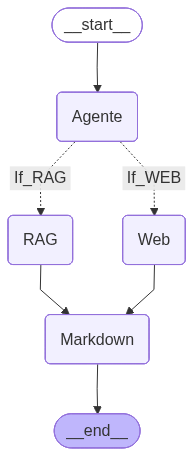

In [79]:
from IPython.display import Image, display

imagen = Agente.get_graph().draw_mermaid_png()
display(Image(imagen))

In [80]:
def ejecutar_agente(pregunta):

  resultado = Agente.invoke({
      "pregunta": pregunta,
      "fuente": "",
      "contexto": "",
      "respuesta": ""
  })

  respuesta_final = resultado["respuesta"]

  print("=" * 60)
  print(f"Fuente utilizada: {resultado["fuente"]}")
  print("=" * 60)
  print(f"Contexto utilizado: {resultado["contexto"]}")
  print("=" * 60)
  print(f"Respuesta final: {respuesta_final}")

  return respuesta_final

In [81]:
ejecutar_agente("Dónde se mantuvo concentrado el mix de productos?")

El agente decidió la fuente RAG.
Fuente utilizada: RAG
Contexto utilizado: El mix de producto se mantuvo concentrado en circuitos combinados (Estambul + Capadocia).
Respuesta final: # Concentración del Mix de Productos

## ¿Dónde se mantuvo concentrado el mix de productos?

Según la información proporcionada, el mix de productos se mantuvo concentrado en:

*   **Circuitos combinados**

Estos circuitos combinados incluían específicamente los siguientes destinos:

*   **Estambul**
*   **Capadocia**


'# Concentración del Mix de Productos\n\n## ¿Dónde se mantuvo concentrado el mix de productos?\n\nSegún la información proporcionada, el mix de productos se mantuvo concentrado en:\n\n*   **Circuitos combinados**\n\nEstos circuitos combinados incluían específicamente los siguientes destinos:\n\n*   **Estambul**\n*   **Capadocia**'